<br>

# 1. Import Libraries & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings for better readability in notebooks
# pd.set_option('display.max_rows', None)
# pd.set_option('display.width', None)
# pd.options.display.max_rows = 10000

<br>

# 2. Load Dataset

In [2]:
# Load Stack Overflow Survey dataset
df = pd.read_csv('Data/stack-overflow-developer-survey-2020/survey_results_public.csv')

# Preview first rows
df.head()

,Respondent,MainBranch,Hobbyist,Age,Age1stCode,CompFreq,CompTotal,ConvertedComp,Country,CurrencyDesc,...,SurveyEase,SurveyLength,Trans,UndergradMajor,WebframeDesireNextYear,WebframeWorkedWith,WelcomeChange,WorkWeekHrs,YearsCode,YearsCodePro
0,1,I am a developer by profession,Yes,NaN,13,Monthly,NaN,NaN,Germany,European Euro,...,Neither easy nor difficult,Appropriate in length,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET;ASP.NET Core,Just as welcome now as I felt last year,50.0,36,27
1,2,I am a developer by profession,No,NaN,19,NaN,NaN,NaN,United Kingdom,Pound sterling,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat more welcome now than last year,NaN,7,4
2,3,I code primarily as a hobby,Yes,NaN,15,NaN,NaN,NaN,Russian Federation,NaN,...,Neither easy nor difficult,Appropriate in length,NaN,NaN,NaN,NaN,Somewhat more welcome now than last year,NaN,4,NaN
3,4,I am a developer by profession,Yes,25.0,18,NaN,NaN,NaN,Albania,Albanian lek,...,NaN,NaN,No,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat less welcome now than last year,40.0,7,4
4,5,"I used to be a developer by profession, but no...",Yes,31.0,16,NaN,NaN,NaN,United States,NaN,...,Easy,Too short,No,"Computer science, computer engineering, or sof...",Django;Ruby on Rails,Ruby on Rails,Just as welcome now as I felt last year,NaN,15,8


<br>

# 3. Data Preprocessing

<br>

###  &emsp; 3.1 Initial Data Exploration

In [3]:
# View a random sample (transposed for better readability of all columns)
df.sample(1).T

,25541
Respondent,25635
MainBranch,I am a student who is learning to code
Hobbyist,Yes
Age,NaN
Age1stCode,10
...,...
WebframeWorkedWith,NaN
WelcomeChange,Just as welcome now as I felt last year
WorkWeekHrs,NaN
YearsCode,5


In [4]:
# Get dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64461 entries, 0 to 64460
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Respondent                    64461 non-null  int64  
 1   MainBranch                    64162 non-null  object 
 2   Hobbyist                      64416 non-null  object 
 3   Age                           45446 non-null  float64
 4   Age1stCode                    57900 non-null  object 
 5   CompFreq                      40069 non-null  object 
 6   CompTotal                     34826 non-null  float64
 7   ConvertedComp                 34756 non-null  float64
 8   Country                       64072 non-null  object 
 9   CurrencyDesc                  45472 non-null  object 
 10  CurrencySymbol                45472 non-null  object 
 11  DatabaseDesireNextYear        44070 non-null  object 
 12  DatabaseWorkedWith            49537 non-null  object 
 13  D

####  Initial Observations

- The dataset contains a large number of features (~60+ columns)
- Many columns have `object` data types (categorical/text data)
- There are significant missing values across multiple columns

These observations indicate that data cleaning and feature selection are required.

<br>

### &emsp;  3.2 Selecting relevant columns for analysis

In [5]:
# Select relevant columns for analysis
# Goal: Understand relationship between job roles (DevType) and technologies
# 'Respondent': unique id (tracking)
# 'Country': regional differences in tech usage


df_core = df[[
    'Respondent','Country','DatabaseDesireNextYear','DatabaseWorkedWith',
    'LanguageDesireNextYear','LanguageWorkedWith','MiscTechDesireNextYear',
    'MiscTechWorkedWith','PlatformDesireNextYear','PlatformWorkedWith',
    'WebframeDesireNextYear','WebframeWorkedWith','DevType'
]]
df_core.head()

,Respondent,Country,DatabaseDesireNextYear,DatabaseWorkedWith,LanguageDesireNextYear,LanguageWorkedWith,MiscTechDesireNextYear,MiscTechWorkedWith,PlatformDesireNextYear,PlatformWorkedWith,WebframeDesireNextYear,WebframeWorkedWith,DevType
0,1,Germany,Microsoft SQL Server,Elasticsearch;Microsoft SQL Server;Oracle,C#;HTML/CSS;JavaScript,C#;HTML/CSS;JavaScript,.NET Core;Xamarin,.NET;.NET Core,Android;iOS;Kubernetes;Microsoft Azure;Windows,Windows,ASP.NET Core,ASP.NET;ASP.NET Core,"Developer, desktop or enterprise applications;..."
1,2,United Kingdom,NaN,NaN,Python;Swift,JavaScript;Swift,React Native;TensorFlow;Unity 3D,React Native,iOS;Kubernetes;Linux;MacOS,iOS,NaN,NaN,"Developer, full-stack;Developer, mobile"
2,3,Russian Federation,NaN,NaN,Objective-C;Python;Swift,Objective-C;Python;Swift,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,United States,MySQL;PostgreSQL,MySQL;PostgreSQL;Redis;SQLite,Java;Ruby;Scala,HTML/CSS;Ruby;SQL,Ansible;Chef,Ansible,Docker;Google Cloud Platform;Heroku;Linux;Windows,AWS;Docker;Linux;MacOS;Windows,Django;Ruby on Rails,Ruby on Rails,NaN


###  Feature Selection Strategy

Since the goal of this project is to understand the relationship between:
- Job roles
- Technologies (languages, tools, frameworks)

The dataset was reduced to include only features relevant to analyzing the relationship between job roles and technologies.<br>
<br>

#### Included:
- **DevType**: Target variable representing job roles
- **WorkedWith columns**: Technologies currently used by professionals
- **DesireNextYear columns**: Technologies professionals aim to learn<br>
<br>

#### Additional:
- **Respondent**: Retained as a unique identifier
- **Country**: Retained to allow potential regional analysis<br>
<br>

This structure enables both:
- Understanding current job requirements
- Exploring future skill trends

<br>

### &emsp;  3.3 Data Preprocessing

#### &emsp;&emsp;3.3.1 Handle `DevType` Column (Target)


In [6]:
# First, we inspect the unique values in the column to understand its structure.
df_core['DevType'].unique().tolist()

['Developer, desktop or enterprise applications;Developer, full-stack',
 'Developer, full-stack;Developer, mobile',
 nan,
 'Designer;Developer, front-end;Developer, mobile',
 'Developer, back-end;Developer, front-end;Developer, QA or test;DevOps specialist',
 'Developer, back-end;Developer, desktop or enterprise applications;Developer, game or graphics',
 'Developer, full-stack',
 'Database administrator;Developer, full-stack;Developer, mobile',
 'Developer, back-end;Developer, desktop or enterprise applications;Developer, embedded applications or devices;Developer, front-end',
 'Designer;Developer, front-end',
 'Designer;Developer, back-end',
 'Developer, desktop or enterprise applications;Developer, front-end',
 'Database administrator;Developer, back-end;Developer, desktop or enterprise applications;Developer, full-stack;Developer, QA or test;DevOps specialist',
 'Developer, back-end',
 'Developer, desktop or enterprise applications',
 'Developer, full-stack;Engineer, data',
 'Devel

### Observations

- There are missing values (`NaN`) in the column
- The column contains multiple roles per entry (multi-label format)
- Most entries start with the word "Developer" followed by a specific role (e.g., "Developer, front-end; Developer, full-stack")
- Roles are separated by semicolons `;`<br>

<br>

### Plan

To clean this column, we will:
- Handle missing values
- Remove the prefix "Developer, " to simplify role names
- Split multiple roles into separate entries
- Standardize and structure the data to make it easier to analyze

In [7]:
# Handle Missing Values in DevType

# Number of missing (null) and non-missing values
null_count = df_core['DevType'].isnull().sum()
not_null_count = df_core.shape[0] - null_count

print('Number of nulls:     ', null_count)
print('Number of not nulls: ', not_null_count)

Number of nulls:      15091
Number of not nulls:  49370


#### Observations

- The `DevType` column contains a significant number of missing values (15,091 records)
- These missing values represent users without a defined job role
- Since `DevType` is the target variable, it is important to handle these values carefully before proceeding with the analysis
<br>

#### Plan

- Handle missing values in the `DevType` column by removing rows with null values, since `DevType` is the target variable and is required for analysis.

- Keep a separate dataset that contains the rows with missing `DevType` values, as these users may later be used for career recommendation.

In [8]:
# Handle missing values in DevType

# separate rows with missing DevType (for future use)
df_no_devtype = df_core[df_core['DevType'].isnull()].copy()

# keep only rows with valid DevType (main dataset)
df_core = df_core[df_core['DevType'].notnull()].copy()
df_core['DevType'].head()

0    Developer, desktop or enterprise applications;...
1              Developer, full-stack;Developer, mobile
5      Designer;Developer, front-end;Developer, mobile
6    Developer, back-end;Developer, front-end;Devel...
7    Developer, back-end;Developer, desktop or ente...
Name: DevType, dtype: object

In [9]:
# split DevType into multiple roles using ';' separator
df_core['DevType'] = df_core['DevType'].str.split(';')
df_core['DevType'].head()

0    [Developer, desktop or enterprise applications...
1           [Developer, full-stack, Developer, mobile]
5    [Designer, Developer, front-end, Developer, mo...
6    [Developer, back-end, Developer, front-end, De...
7    [Developer, back-end, Developer, desktop or en...
Name: DevType, dtype: object

In [10]:
# remove "Developer, " from each career
df_core['DevType'] = df_core['DevType'].apply(
    lambda careers: [career.replace('Developer, ', '').strip() for career in careers]
)

df_core['DevType'].head()

0     [desktop or enterprise applications, full-stack]
1                                 [full-stack, mobile]
5                        [Designer, front-end, mobile]
6    [back-end, front-end, QA or test, DevOps speci...
7    [back-end, desktop or enterprise applications,...
Name: DevType, dtype: object

In [11]:
# get frequency of each DevType role
df_core['DevType'].explode().value_counts()

back-end                                         27228
full-stack                                       27125
front-end                                        18296
desktop or enterprise applications               11784
mobile                                            9482
DevOps specialist                                 5969
Database administrator                            5722
Designer                                          5321
System administrator                              5242
embedded applications or devices                  4750
Data or business analyst                          4024
Data scientist or machine learning specialist     3988
QA or test                                        3947
Engineer, data                                    3738
Academic researcher                               3552
Educator                                          2928
game or graphics                                  2789
Engineering manager                               2724
Product ma

In [12]:
# count the number of careers (DevTypes) in each row
df_core['Career_nums'] = df_core['DevType'].apply(len)
df_core[['DevType','Career_nums']].head()


,DevType,Career_nums
0,"[desktop or enterprise applications, full-stack]",2
1,"[full-stack, mobile]",2
5,"[Designer, front-end, mobile]",3
6,"[back-end, front-end, QA or test, DevOps speci...",4
7,"[back-end, desktop or enterprise applications,...",3


(array([3.2446e+04, 1.0162e+04, 4.1420e+03, 1.5540e+03, 6.1400e+02,
        2.9600e+02, 6.2000e+01, 3.1000e+01, 1.5000e+01, 4.8000e+01]),
 array([ 1. ,  3.2,  5.4,  7.6,  9.8, 12. , 14.2, 16.4, 18.6, 20.8, 23. ]),
 <BarContainer object of 10 artists>)

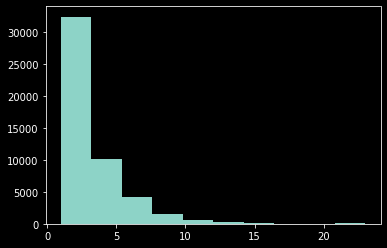

In [13]:
# visualize the distribution of the number of careers per user
# this helps understand the overall pattern in the data
plt.hist(df_core['Career_nums'],bins=10)

#### Observations

- The distribution shows that most users have a small number of careers
- A small portion of users have a high number of careers, which may represent noisy or unrealistic data.<br>
<br>

#### Plan

- Use the 90th percentile as a threshold to identify outliers
- Remove rows where the number of careers exceeds this threshold (greater than 6)
- This helps reduce noise while keeping the majority of valid data

90th percentile (threshold): 6.0


(array([13780.,     0.,  9796.,     0.,  8870.,     0.,  6171.,     0.,
         3991.,  2573.]),
 array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ]),
 <BarContainer object of 10 artists>)

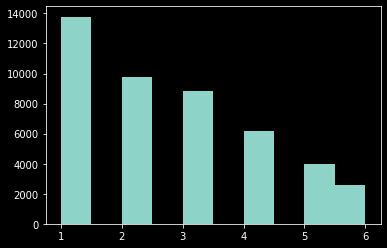

In [14]:
# calculate the 90th percentile of Career_nums
threshold = df_core['Career_nums'].quantile(0.90)

print('90th percentile (threshold):', threshold)


# remove rows where number of careers exceeds the threshold
df_core = df_core[df_core['Career_nums'] <= threshold]

# visualize the distribution of the number of careers per user
plt.hist(df_core['Career_nums'],bins=10)

<br>
<br>

#### &emsp;&emsp;3.3.2 Handle Feature Columns (Feature Engineering)



### Overview

In this step, we construct a unified feature called `skills` by combining multiple technology-related columns into a single structured representation.

The objective is to represent each user by a comprehensive set of technologies that reflect both their current experience and relevant technical exposure.

This unified representation will later be used to analyze the relationship between skills and job roles (`DevType`), enabling a mapping between technologies and careers.

<br>

### Strategy

- Combine both **"WorkedWith"** and **"DesireNextYear"** columns to capture a broader set of relevant technologies associated with each user
- Exclude platform-related features as they are less relevant for career classification
- Convert each selected column into a list of skills
- Handle missing values by replacing them with empty lists
- Merge all skill-related columns into a single unified feature (`skills`)
- Remove duplicate values within each row to ensure a clean and consistent representation

In [15]:
# Convert each column into a list of skills


# select feature columns 
all_columns = list(df_core.columns.values)
excluded_columns=['Respondent','Country','DevType','Career_nums',
               'PlatformDesireNextYear','PlatformWorkedWith']
feature_columns  = [x for x in all_columns if x not in excluded_columns]

# convert each feature column into a list of skills
# split values by ';' to separate multiple technologies
for col in feature_columns :
    df_core[col] = df_core[col].str.split(';')
    
    # handle missing values by replacing non-lists with empty lists
    df_core[col] = [x if isinstance(x, list) else [] for x in df_core[col]]
    
df_core[feature_columns].head()

,DatabaseDesireNextYear,DatabaseWorkedWith,LanguageDesireNextYear,LanguageWorkedWith,MiscTechDesireNextYear,MiscTechWorkedWith,WebframeDesireNextYear,WebframeWorkedWith
0,[Microsoft SQL Server],"[Elasticsearch, Microsoft SQL Server, Oracle]","[C#, HTML/CSS, JavaScript]","[C#, HTML/CSS, JavaScript]","[.NET Core, Xamarin]","[.NET, .NET Core]",[ASP.NET Core],"[ASP.NET, ASP.NET Core]"
1,[],[],"[Python, Swift]","[JavaScript, Swift]","[React Native, TensorFlow, Unity 3D]",[React Native],[],[]
5,[],[],"[HTML/CSS, Java, JavaScript]","[HTML/CSS, Java, JavaScript]",[],[],[React.js],[]
6,[],[],"[C#, HTML/CSS, PHP]","[C#, HTML/CSS, PHP]",[],[],[],[]
7,[MongoDB],"[MariaDB, MySQL, Redis]",[JavaScript],"[Python, SQL]",[Unity 3D],[Ansible],"[Django, React.js, Vue.js]",[Flask]


In [16]:
# Merging all skill-related columns into one unified feature

# initialize empty skills column for each user
df_core['skills'] = [[] for _ in range(len(df_core))]

# merge all feature columns into a single list of skills per user
for col in feature_columns:
    df_core['skills'] = df_core['skills'] + df_core[col] 
    
df_core['skills'].head()


0    [Microsoft SQL Server, Elasticsearch, Microsof...
1    [Python, Swift, JavaScript, Swift, React Nativ...
5    [HTML/CSS, Java, JavaScript, HTML/CSS, Java, J...
6               [C#, HTML/CSS, PHP, C#, HTML/CSS, PHP]
7    [MongoDB, MariaDB, MySQL, Redis, JavaScript, P...
Name: skills, dtype: object

In [17]:
# Remove duplicate skills within each row to create a clean and unified `skills` column

# remove duplicate skills while preserving order
df_core['skills'] = [
    list(dict.fromkeys(skills)) if isinstance(skills, list) else []
    for skills in df_core['skills']
]

df_core['skills'].head()

0    [Microsoft SQL Server, Elasticsearch, Oracle, ...
1    [Python, Swift, JavaScript, React Native, Tens...
5               [HTML/CSS, Java, JavaScript, React.js]
6                                  [C#, HTML/CSS, PHP]
7    [MongoDB, MariaDB, MySQL, Redis, JavaScript, P...
Name: skills, dtype: object